# Sumarização de Textos com PLN: Algoritmo de Luhn
**Autor: Wellington M Santos - Data Scientist**  
[![LinkedIn](https://img.shields.io/badge/LinkedIn-wellington--moreira--santos-blue)](https://www.linkedin.com/in/wellington-moreira-santos)
[![Email](https://img.shields.io/badge/Email-wsantos08%40hotmail.com-red)](mailto:wsantos08@hotmail.com)


---

## 1. Introdução

No projeto [Algoritmo Baseado em Frequência](Algoritmo%20baseado%20em%20frequencia.ipynb) implementei sumarização por frequência simples: conto palavras, normalizo pesos, somo a pontuação de cada sentença. Funciona, mas tem um ponto cego. Uma sentença pode acumular uma nota alta só porque contém várias palavras importantes espalhadas por ela inteira, mesmo que essas palavras estejam distantes umas das outras e sem relação direta de sentido.

Foi exatamente esse ponto cego que Hans Peter Luhn endereçou em 1958, num dos primeiros papers da história sobre sumarização automática. A ideia dele introduz um conceito novo: a proximidade. Palavras importantes que aparecem próximas umas das outras dentro de uma sentença formam um "cluster" significativo, e esse cluster é o que realmente indica que a sentença carrega conteúdo relevante. Uma sentença com termos importantes dispersos pontua menos do que uma sentença mais curta, mas com termos importantes concentrados.

Neste projeto, implemento o algoritmo de Luhn do zero, comparo com a abordagem por frequência simples, e expando o pipeline para um caso de uso mais completo: leitura de feeds RSS, geração de nuvem de palavras, extração de entidades nomeadas e exportação dos resumos em HTML.

**Referência teórica:** [Luhn, H.P. (1958). The Automatic Creation of Literature Abstracts](https://courses.ischool.berkeley.edu/i256/f06/papers/luhn58.pdf)

**Stack utilizada:** `Python 3.10+`, `nltk`, `collections`, `heapq`, `re`, `string`, `newspaper4k`, `feedparser`, `beautifulsoup4`, `wordcloud`, `matplotlib`, `spacy>=3.x`, `rouge-score`, `IPython.display`

**Seções:**

1. Introdução
2. Instalação e Configuração
3. Pré-processamento do Texto
4. A Lógica do Algoritmo de Luhn
5. Função de Sumarização
6. Visualização do Resumo
7. Extração de Texto da Web
8. Leitura de Feed RSS
9. Nuvem de Palavras
10. Extração de Entidades Nomeadas
11. Sumarização em Lote com Exportação HTML
12. Extensão: Lematização com spaCy
13. Avaliação com ROUGE: Luhn vs. Frequência Simples
14. Conclusão e Considerações Finais


---


## 2. Instalação e Configuração


In [2]:
# Instalar dependências
# !pip install nltk newspaper4k feedparser beautifulsoup4 wordcloud matplotlib spacy rouge-score
# !python -m spacy download pt_core_news_sm

In [3]:
import re
import os
import json
import string
import heapq
from collections import Counter

import nltk
from IPython.display import HTML, display

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\wsant\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\wsant\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wsant\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

---

## 3. Pré-processamento do Texto

A normalização segue a mesma lógica do projeto de frequência simples: lowercase, tokenização, remoção de stopwords e pontuação. A diferença aqui é que vou adicionar duas stopwords customizadas ao vocabulário padrão, "ser" e "além", que no texto de exemplo aparecem com frequência mas não carregam carga temática relevante.


In [4]:
texto_original = """A inteligência artificial é a inteligência similar à humana máquinas.
                    Definem como o estudo de agente artificial com inteligência.
                    Ciência e engenharia de produzir máquinas com inteligência.
                    Resolver problemas e possuir inteligência.
                    Relacionada ao comportamento inteligente.
                    Construção de máquinas para raciocinar.
                    Aprender com os erros e acertos.
                    Inteligência artificial é raciocinar nas situações do cotidiano."""

texto_original = re.sub(r'\s+', ' ', texto_original)
print(texto_original)

A inteligência artificial é a inteligência similar à humana máquinas. Definem como o estudo de agente artificial com inteligência. Ciência e engenharia de produzir máquinas com inteligência. Resolver problemas e possuir inteligência. Relacionada ao comportamento inteligente. Construção de máquinas para raciocinar. Aprender com os erros e acertos. Inteligência artificial é raciocinar nas situações do cotidiano.


In [5]:
stopwords = nltk.corpus.stopwords.words('portuguese')
stopwords.extend(['ser', 'além'])
print(f"Total de stopwords: {len(stopwords)}")

Total de stopwords: 209


In [6]:
def preprocessamento(texto):
    """
    Normaliza o texto: lowercase, tokenização, remoção de stopwords e pontuação.

    Parâmetros:
        texto (str): texto bruto de entrada

    Retorna:
        str: string com tokens relevantes separados por espaço
    """
    texto_formatado = texto.lower()
    tokens = nltk.word_tokenize(texto_formatado, language='portuguese')
    tokens = [
        palavra for palavra in tokens
        if palavra not in stopwords and palavra not in string.punctuation
    ]
    return ' '.join([t for t in tokens if not t.isdigit()])

---

## 4. A Lógica do Algoritmo de Luhn

Aqui está a diferença central em relação ao projeto baseado em frequência. Em vez de somar diretamente os pesos das palavras importantes em cada sentença, o algoritmo de Luhn segue três passos:

1. Localizo, dentro de cada sentença, as posições onde aparecem as palavras consideradas importantes (as `top_n` mais frequentes do texto).
2. Agrupo essas posições em clusters: se a distância entre duas palavras importantes consecutivas for menor que um limiar definido, elas pertencem ao mesmo cluster.
3. Calculo a nota de cada cluster com a fórmula original de Luhn: o quadrado do número de palavras importantes no cluster, dividido pelo total de palavras que o cluster ocupa. A nota da sentença é a nota do melhor cluster encontrado nela.

Essa fórmula penaliza clusters "esticados": um cluster com 3 palavras importantes espalhadas em 10 posições pontua menos do que um cluster com as mesmas 3 palavras concentradas em 4 posições.

In [7]:
def calcula_nota_sentenca(sentencas, palavras_importantes, distancia):
    """
    Calcula a nota de cada sentença segundo o algoritmo de Luhn.

    Parâmetros:
        sentencas (list[str]): sentenças já pré-processadas
        palavras_importantes (list[str]): top N palavras mais frequentes do texto
        distancia (int): distância máxima entre posições para formar um cluster

    Retorna:
        list[tuple[float, int]]: pares (nota, índice_da_sentença)
    """
    notas = []

    for indice_sentenca, sentenca in enumerate(
        [nltk.word_tokenize(s.lower(), language='portuguese') for s in sentencas]
    ):
        indices_palavra = []
        for palavra in palavras_importantes:
            if palavra in sentenca:
                indices_palavra.append(sentenca.index(palavra))

        if not indices_palavra:
            continue

        indices_palavra.sort()

        # Agrupa índices próximos em clusters
        lista_grupos = []
        grupo = [indices_palavra[0]]
        for i in range(1, len(indices_palavra)):
            if indices_palavra[i] - indices_palavra[i - 1] < distancia:
                grupo.append(indices_palavra[i])
            else:
                lista_grupos.append(grupo)
                grupo = [indices_palavra[i]]
        lista_grupos.append(grupo)

        # Nota da sentença = nota do melhor cluster
        nota_maxima_grupo = 0
        for g in lista_grupos:
            palavras_importantes_no_grupo = len(g)
            total_palavras_no_grupo = g[-1] - g[0] + 1
            nota = 1.0 * palavras_importantes_no_grupo ** 2 / total_palavras_no_grupo
            nota_maxima_grupo = max(nota_maxima_grupo, nota)

        notas.append((nota_maxima_grupo, indice_sentenca))

    return notas


---


## 5. Função de Sumarização

A função `sumarizar` orquestra o pipeline inteiro: tokeniza sentenças, pré-processa cada uma, calcula a frequência das palavras, seleciona as `top_n` mais relevantes, e delega a pontuação para `calcula_nota_sentenca`.


In [8]:
def sumarizar(texto, top_n_palavras, distancia, quantidade_sentencas):
    """
    Executa o pipeline completo de sumarização pelo algoritmo de Luhn.

    Parâmetros:
        texto (str): texto original a ser sumarizado
        top_n_palavras (int): quantidade de palavras mais frequentes consideradas importantes
        distancia (int): distância máxima entre posições para formar um cluster
        quantidade_sentencas (int): número de sentenças no resumo

    Retorna:
        tuple: (sentencas_originais, melhores_sentencas, notas_sentencas)
    """
    sentencas_originais = nltk.sent_tokenize(texto, language='portuguese')
    sentencas_formatadas = [preprocessamento(s) for s in sentencas_originais]

    palavras = [
        palavra for sentenca in sentencas_formatadas
        for palavra in nltk.word_tokenize(sentenca)
    ]
    frequencia = Counter(palavras)
    top_palavras = [palavra for palavra, _ in frequencia.most_common(top_n_palavras)]

    notas_sentencas = calcula_nota_sentenca(sentencas_formatadas, top_palavras, distancia)
    melhores = heapq.nlargest(quantidade_sentencas, notas_sentencas)
    melhores_sentencas = [sentencas_originais[i] for (_, i) in melhores]

    return sentencas_originais, melhores_sentencas, notas_sentencas

In [9]:
sentencas_originais, melhores_sentencas, notas_sentencas = sumarizar(
    texto_original, top_n_palavras=5, distancia=3, quantidade_sentencas=3
)

print("Sentenças selecionadas:")
for s in melhores_sentencas:
    print(f"  - {s}")

print("\nNotas (nota, índice):")
print(notas_sentencas)

Sentenças selecionadas:
  - Inteligência artificial é raciocinar nas situações do cotidiano.
  - A inteligência artificial é a inteligência similar à humana máquinas.
  - Construção de máquinas para raciocinar.

Notas (nota, índice):
[(2.6666666666666665, 0), (2.0, 1), (2.0, 2), (1.0, 3), (2.0, 5), (3.0, 7)]



Três hiperparâmetros entram em jogo aqui: `top_n_palavras` define quantas palavras contam como "importantes", `distancia` define o quão próximas elas precisam estar para formar um cluster, e `quantidade_sentencas` define o tamanho do resumo final. Vale testar combinações diferentes para sentir o impacto de cada um.

---


## 6. Visualização do Resumo

Mantenho a mesma estratégia de visualização já utilizada anteriormente no projeto [baseado em frequências](Algoritmo%20baseado%20em%20frequencia.ipynb): detecto o ambiente de execução e ofereço HTML com destaque no Jupyter, ou texto puro como fallback em outros contextos.

In [10]:
def visualiza_resumo(titulo, lista_sentencas, melhores_sentencas):
    """
    Exibe o texto original com as sentenças do resumo destacadas.
    Suporta Jupyter (HTML) e outros ambientes (texto puro).

    Parâmetros:
        titulo (str): título exibido no cabeçalho
        lista_sentencas (list): todas as sentenças do texto original
        melhores_sentencas (list): sentenças selecionadas para o resumo
    """
    try:
        get_ipython  # noqa
        texto_html = ''
        for sentenca in lista_sentencas:
            if sentenca in melhores_sentencas:
                texto_html += f'<mark>{sentenca}</mark> '
            else:
                texto_html += sentenca + ' '
        display(HTML(f'<h3>Resumo: {titulo}</h3><p>{texto_html}</p>'))
    except NameError:
        print(f"\n=== Resumo: {titulo} ===")
        for sentenca in lista_sentencas:
            marcador = ">> " if sentenca in melhores_sentencas else "   "
            print(f"{marcador}{sentenca}")


In [11]:

visualiza_resumo('Texto de Exemplo', sentencas_originais, melhores_sentencas)


---



## 7. Extração de Texto da Web

In [12]:

# !pip install newspaper4k

In [13]:
from newspaper import Article

def extrair_artigo(url):
    """
    Extrai título e texto principal de uma URL usando newspaper4k.

    Parâmetros:
        url (str): endereço do artigo

    Retorna:
        tuple: (titulo, texto) ou (None, None) em caso de erro
    """
    try:
        artigo = Article(url, language='pt')
        artigo.download()
        artigo.parse()
        return artigo.title, artigo.text
    except Exception as e:
        print(f"Erro ao extrair {url}: {e}")
        return None, None

In [14]:
url = 'https://agenciabrasil.ebc.com.br/economia/noticia/2024-01/fmi-inteligencia-artificial-afetara-40-dos-empregos-em-todo-o-mundo'
titulo, texto = extrair_artigo(url)

print(f"Título: {titulo}")
print(f"Tamanho do texto: {len(texto)} caracteres")

Título: FMI: inteligência artificial afetará 40% dos empregos em todo o mundo
Tamanho do texto: 2124 caracteres


In [15]:
sentencas_originais, melhores_sentencas, notas_sentencas = sumarizar(
    texto, top_n_palavras=20, distancia=5, quantidade_sentencas=5
)
visualiza_resumo(titulo, sentencas_originais, melhores_sentencas)


Reparo que em textos reais, mais longos que o exemplo didático, preciso aumentar `top_n_palavras` e `distancia` proporcionalmente. Com `top_n_palavras=5` num artigo de centenas de palavras, praticamente nenhuma sentença teria termos importantes suficientes para formar um cluster relevante.



---



## 8. Leitura de Feed RSS

Aqui vou coletar um feed institucional estável e de fácil verificação: o feed da Agência Brasil.


In [16]:

# !pip install feedparser beautifulsoup4


In [17]:
import feedparser
from bs4 import BeautifulSoup

# url_feed = 'https://agenciabrasil.ebc.com.br/feed/'
url_feed = 'http://agenciabrasil.ebc.com.br/rss/ultimasnoticias/feed.xml'
feed = feedparser.parse(url_feed)

print(f"Total de entradas no feed: {len(feed.entries)}")
print(f"Título do feed: {feed.feed.get('title', 'N/A')}")

Total de entradas no feed: 10
Título do feed: Feed Últimas


In [18]:
for entrada in feed.entries[:3]:
    print(entrada.title)
    print(entrada.link)
    print('---')

Defesa diz que julgamento da morte de Gritzbach foi manipulado
https://agenciabrasil.ebc.com.br/justica/noticia/2026-06/defesa-diz-que-julgamento-da-morte-de-gritzbach-foi-manipulado
---
Em carta deixada em vestiário, seleção iraniana pede paz entre nações
https://agenciabrasil.ebc.com.br/internacional/noticia/2026-06/em-carta-deixada-no-vestiario-selecao-iraniana-pede-paz-entre-nacoes
---
Mercado eleva projeção de inflação e vê Selic em 14% ao ano em 2026
https://agenciabrasil.ebc.com.br/economia/noticia/2026-06/mercado-eleva-projecao-de-inflacao-e-ve-selic-em-14-ao-ano-em-2026
---



O conteúdo de cada entrada vem com tags HTML embutidas. Preciso limpar isso antes de alimentar o pipeline de sumarização.


In [19]:
def limpa_html(texto):
    """
    Remove tags HTML de um trecho de texto, retornando apenas o conteúdo textual.

    Parâmetros:
        texto (str): texto com marcação HTML

    Retorna:
        str: texto limpo
    """
    if not texto:
        return ''
    return BeautifulSoup(texto, 'html.parser').get_text()

In [20]:
artigos_feed = []
for entrada in feed.entries:
    conteudo_bruto = entrada.get('summary', '') or entrada.get('description', '')
    artigos_feed.append({
        'titulo': entrada.title,
        'link': entrada.link,
        'conteudo': limpa_html(conteudo_bruto)
    })

print(f"Artigos processados: {len(artigos_feed)}")
print(artigos_feed[0])

Artigos processados: 10
{'titulo': 'Defesa diz que julgamento da morte de Gritzbach foi manipulado', 'link': 'https://agenciabrasil.ebc.com.br/justica/noticia/2026-06/defesa-diz-que-julgamento-da-morte-de-gritzbach-foi-manipulado', 'conteudo': '\n\nSob forte esquema de segurança, tem início hoje (22), no Fórum Criminal de Guarulhos, o julgamento de três policiais militares acusados de participar\xa0do assassinato do empresário e delator Vinicius Gritzbach.\nO julgamento terá início com a seleção dos sete jurados que vão compor o júri popular. A previsão inicial é de que o júri dure em torno de cinco dias.\nNotícias relacionadas:MP do Paraná coordena megaoperação contra o crime organizado.Operação da PF combate núcleo financeiro do Comando Vermelho .Enquanto o\xa0julgamento estiver ocorrendo, as demais audiências do Fórum de Guarulhos ficarão suspensas. Também foi estabelecida uma área de segurança ao redor do fórum, com bloqueios de ruas.\n\xa0O julgamento dos policiais será conduzido 


Uso `html.parser`, nativo do `BeautifulSoup`, em vez de `html5lib`. Evita uma dependência extra e é suficiente para limpar marcação simples de feeds RSS.


In [21]:
# Persistindo os artigos em disco para reuso
with open('feed_agencia_brasil.json', 'w', encoding='utf-8') as arquivo:
    json.dump(artigos_feed, arquivo, indent=2, ensure_ascii=False)

In [22]:
with open('feed_agencia_brasil.json', encoding='utf-8') as arquivo:
    artigos_feed = json.load(arquivo)

In [23]:
artigos_feed

[{'titulo': 'Defesa diz que julgamento da morte de Gritzbach foi manipulado',
  'link': 'https://agenciabrasil.ebc.com.br/justica/noticia/2026-06/defesa-diz-que-julgamento-da-morte-de-gritzbach-foi-manipulado',
  'conteudo': '\n\nSob forte esquema de segurança, tem início hoje (22), no Fórum Criminal de Guarulhos, o julgamento de três policiais militares acusados de participar\xa0do assassinato do empresário e delator Vinicius Gritzbach.\nO julgamento terá início com a seleção dos sete jurados que vão compor o júri popular. A previsão inicial é de que o júri dure em torno de cinco dias.\nNotícias relacionadas:MP do Paraná coordena megaoperação contra o crime organizado.Operação da PF combate núcleo financeiro do Comando Vermelho .Enquanto o\xa0julgamento estiver ocorrendo, as demais audiências do Fórum de Guarulhos ficarão suspensas. Também foi estabelecida uma área de segurança ao redor do fórum, com bloqueios de ruas.\n\xa0O julgamento dos policiais será conduzido pelo juiz Rodrigo T

---

## 9. Nuvem de Palavras

Uma forma visual e rápida de inspecionar o vocabulário dominante de um conjunto de textos é a nuvem de palavras. Concateno o conteúdo de todos os artigos do feed, pré-processo, e gero a visualização.


In [24]:
conteudo_feed = ' '.join(artigo['conteudo'] for artigo in artigos_feed)
conteudo_feed_formatado = preprocessamento(conteudo_feed)

print(f"Tamanho original: {len(conteudo_feed)} caracteres")
print(f"Tamanho pré-processado: {len(conteudo_feed_formatado)} caracteres")

Tamanho original: 37161 caracteres
Tamanho pré-processado: 28356 caracteres


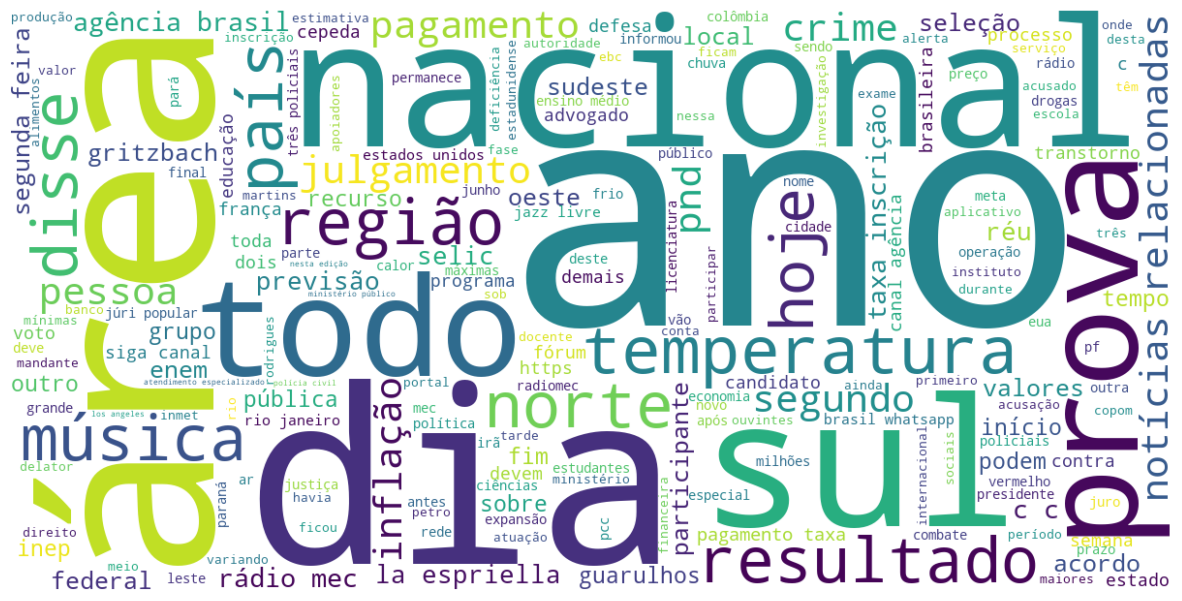

In [25]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

nuvem = WordCloud(width=1200, height=600, background_color='white').generate(conteudo_feed_formatado)

plt.figure(figsize=(15, 8))
plt.axis('off')
plt.imshow(nuvem, interpolation='bilinear')
plt.show()


A nuvem dá uma leitura instantânea dos temas predominantes no feed no momento da coleta, sem precisar ler artigo por artigo.


---



## 10. Extração de Entidades Nomeadas

Além de sumarizar, também posso extrair entidades nomeadas (pessoas, organizações, locais) do conteúdo, o que enriquece a análise do material coletado. Uso o spaCy 3.x com o modelo oficial para português.


In [26]:
# !python -m spacy download pt_core_news_sm
import spacy

pln = spacy.load('pt_core_news_sm')

In [27]:

documento = pln(conteudo_feed_formatado)

In [28]:
from spacy import displacy

# Em Jupyter, exibe as entidades destacadas no texto
displacy.render(documento, style='ent', jupyter=True)

In [29]:
# Filtrando apenas localizações (LOC)
locais = [ent.text for ent in documento.ents if ent.label_ == 'LOC']
print(f"Locais identificados: {set(locais)}")

Locais identificados: {'los angeles', 'pará', 'estados unidos', 'sul paulista', 'rio grande', 'acre', 'letras', 'khz belo horizonte', 'guarulhos foto paulo', 'ibge', 'minas gerais espírito santo sul', 'tocantins', 'colômbia', 'rio janeiro', 'rio grande sul', 'brasil', 'aeroporto internacional guarulhos', 'califórnia', 'itália', 'frança', 'tijuana méxico', 'fórum criminal guarulhos julgamento', 'canadá méxico', 'europa', 'espanha', 'estado paulo triângulo mineiro', 'santa catarina', 'bélgica los angeles', 'bélgica', 'bogotá', 'eua', 'forçará', 'colômbia peru', 'espírito irã'}


In [30]:
# Contagem de entidades por tipo
contagem_entidades = Counter(ent.label_ for ent in documento.ents)
print(contagem_entidades)

Counter({'LOC': 69, 'PER': 51, 'ORG': 11, 'MISC': 7})



Vale notar que o pré-processamento remove pontuação e capitalização, o que pode prejudicar levemente o reconhecimento de entidades pelo spaCy (capitalização é um sinal importante para o modelo). Em um pipeline de produção, rodar o NER sobre o texto original, não o pré-processado, costuma dar resultados melhores.



---



## 11. Sumarização em Lote com Exportação HTML

Fecho o pipeline aplicando a sumarização sobre todos os artigos do feed e exportando cada resumo como um arquivo HTML independente, útil para arquivar ou compartilhar fora do notebook.



In [31]:
def salva_resumo(titulo, lista_sentencas, melhores_sentencas, pasta_saida='resumos'):
    """
    Salva o resumo de um artigo como arquivo HTML standalone.

    Parâmetros:
        titulo (str): título do artigo, usado no nome do arquivo
        lista_sentencas (list): todas as sentenças do texto original
        melhores_sentencas (list): sentenças selecionadas para o resumo
        pasta_saida (str): diretório onde o HTML será salvo
    """
    os.makedirs(pasta_saida, exist_ok=True)

    html_template = """<html>
<head>
  <title>{0}</title>
  <meta http-equiv="Content-Type" content="text/html; charset=UTF-8" />
</head>
<body>{1}</body>
</html>"""

    texto = ''
    for sentenca in lista_sentencas:
        if sentenca in melhores_sentencas:
            texto += f'<mark>{sentenca}</mark> '
        else:
            texto += sentenca + ' '

    nome_arquivo = re.sub(r'[^\w\s-]', '', titulo).strip().replace(' ', '_')[:80]
    caminho = os.path.join(pasta_saida, f'{nome_arquivo}.html')

    with open(caminho, 'w', encoding='utf-8') as arquivo:
        arquivo.write(html_template.format(f'{titulo} - resumo', texto))

    return caminho

In [32]:
for artigo in artigos_feed:
    sentencas_originais, melhores_sentencas, _ = sumarizar(
        artigo['conteudo'], top_n_palavras=15, distancia=5, quantidade_sentencas=3
    )
    visualiza_resumo(artigo['titulo'], sentencas_originais, melhores_sentencas)
    caminho = salva_resumo(artigo['titulo'], sentencas_originais, melhores_sentencas)
    print(f"Resumo salvo em: {caminho}")

Resumo salvo em: resumos\Defesa_diz_que_julgamento_da_morte_de_Gritzbach_foi_manipulado.html


Resumo salvo em: resumos\Em_carta_deixada_em_vestiário_seleção_iraniana_pede_paz_entre_nações.html


Resumo salvo em: resumos\Mercado_eleva_projeção_de_inflação_e_vê_Selic_em_14_ao_ano_em_2026.html


Resumo salvo em: resumos\Candidatos_ao_Enem_têm_até_a_noite_desta_segunda_para_pagar_inscrição.html


Resumo salvo em: resumos\Temperaturas_devem_ultrapassar_40C_em_onda_de_calor_europeia.html


Resumo salvo em: resumos\Programa_Jazz_Livre_dedica_episódio_aos_90_anos_de_Hermeto_Pascoal.html


Resumo salvo em: resumos\Operação_da_PF_combate_núcleo_financeiro_do_Comando_Vermelho.html


Resumo salvo em: resumos\PND_2026_professores_podem_se_inscrever_a_partir_de_segunda-feira.html


Resumo salvo em: resumos\Inmet_prevê_segunda_sob_frio_intenso_no_Sudeste.html


Resumo salvo em: resumos\Candidato_de_direita_La_Espriella_vence_disputa_acirrada_na_Colômbia.html



Sanitizo o título antes de usá-lo como nome de arquivo (removendo caracteres que o sistema de arquivos rejeitaria) e crio a pasta de saída automaticamente com `os.makedirs`.



---



## 12. Extensão: Lematização com spaCy

Como no projeto de frequência simples, comparo a tokenização padrão com uma variante que usa lematização. A motivação se mantém: reduzir variações morfológicas da mesma palavra a uma forma canônica, evitando que "corrida", "corrido" e "correr" sejam tratados como termos independentes na contagem de frequência.


In [33]:
def preprocessamento_lematizacao(texto):
    """
    Variante do pré-processamento com lematização via spaCy 3.x.

    Parâmetros:
        texto (str): texto bruto de entrada

    Retorna:
        str: string com lemas relevantes separados por espaço
    """
    texto = re.sub(r'\s+', ' ', texto.lower())
    documento = pln(texto)
    tokens = [
        token.lemma_ for token in documento
        if token.lemma_ not in stopwords
        and token.lemma_ not in string.punctuation
        and not token.is_digit
        and not token.is_space
    ]
    return ' '.join(tokens)

In [34]:

def sumarizar_lematizacao(texto, top_n_palavras, distancia, quantidade_sentencas):
    """
    Pipeline de sumarização pelo algoritmo de Luhn com pré-processamento por lematização.
    Mesma estrutura de sumarizar(), substituindo a função de pré-processamento.
    """
    sentencas_originais = nltk.sent_tokenize(texto, language='portuguese')
    sentencas_formatadas = [preprocessamento_lematizacao(s) for s in sentencas_originais]

    palavras = [
        palavra for sentenca in sentencas_formatadas
        for palavra in nltk.word_tokenize(sentenca)
    ]
    frequencia = Counter(palavras)
    top_palavras = [palavra for palavra, _ in frequencia.most_common(top_n_palavras)]

    notas_sentencas = calcula_nota_sentenca(sentencas_formatadas, top_palavras, distancia)
    melhores = heapq.nlargest(quantidade_sentencas, notas_sentencas)
    melhores_sentencas = [sentencas_originais[i] for (_, i) in melhores]

    return sentencas_originais, melhores_sentencas, notas_sentencas

In [35]:
sentencas_originais, melhores_sentencas, _ = sumarizar(
    artigos_feed[0]['conteudo'], top_n_palavras=15, distancia=5, quantidade_sentencas=3
)
visualiza_resumo(f"{artigos_feed[0]['titulo']} (tokenização simples)", sentencas_originais, melhores_sentencas)

In [36]:

sentencas_originais, melhores_sentencas, _ = sumarizar_lematizacao(
    artigos_feed[0]['conteudo'], top_n_palavras=15, distancia=5, quantidade_sentencas=3
)
visualiza_resumo(f"{artigos_feed[0]['titulo']} (lematização)", sentencas_originais, melhores_sentencas)


---


## 13. Avaliação com ROUGE: Luhn vs. Frequência Simples

No projeto anterior, fechei com uma avaliação ROUGE isolada. Aqui aproveito para ir além: comparo diretamente o algoritmo de Luhn com o algoritmo de frequência simples sobre o mesmo artigo, usando o mesmo resumo de referência.


In [44]:
# !pip install rouge-score
from rouge_score import rouge_scorer

In [45]:
def avaliar_rouge(resumo_gerado, resumo_referencia):
    """
    Calcula métricas ROUGE entre o resumo gerado e o de referência.

    Parâmetros:
        resumo_gerado (str): resumo produzido pelo algoritmo
        resumo_referencia (str): resumo de referência escrito por humano

    Retorna:
        dict: scores ROUGE-1, ROUGE-2 e ROUGE-L (precision, recall, f1)
    """
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    return scorer.score(resumo_referencia.strip(), resumo_gerado.strip())

In [46]:
# Resumo de referência escrito manualmente a partir do artigo do FMI
# Fonte: https://agenciabrasil.ebc.com.br/economia/noticia/2024-01/fmi-inteligencia-artificial-afetara-40-dos-empregos-em-todo-o-mundo
resumo_referencia = """
O FMI alerta que a inteligência artificial afetará 40% dos empregos em todo o mundo,
com impacto ainda maior nas economias avançadas, onde 60% dos postos de trabalho
serão impactados. A diretora-geral do fundo ressalta que os efeitos não são
necessariamente negativos e podem resultar em aumento de rendimentos, mas alerta
para o risco de aprofundamento das desigualdades entre países com diferentes
capacidades de adaptação tecnológica.
"""

url_fmi = 'https://agenciabrasil.ebc.com.br/economia/noticia/2024-01/fmi-inteligencia-artificial-afetara-40-dos-empregos-em-todo-o-mundo'
_, texto_fmi = extrair_artigo(url_fmi)

In [47]:
# Resumo gerado pelo algoritmo de Luhn
_, melhores_luhn, _ = sumarizar(texto_fmi, top_n_palavras=20, distancia=5, quantidade_sentencas=5)
resumo_luhn = ' '.join(melhores_luhn)

# Resumo gerado pelo algoritmo de frequência simples (projeto anterior)
def sumarizar_frequencia_simples(texto, quantidade_sentencas):
    """Reimplementação compacta do algoritmo de frequência simples para comparação."""
    texto_formatado = preprocessamento(texto)
    contagem = Counter(nltk.word_tokenize(texto_formatado))
    freq_max = max(contagem.values())
    pesos = {p: f / freq_max for p, f in contagem.items()}

    sentencas = nltk.sent_tokenize(texto, language='portuguese')
    notas = {}
    for sentenca in sentencas:
        for palavra in nltk.word_tokenize(sentenca.lower(), language='portuguese'):
            if palavra in pesos:
                notas[sentenca] = notas.get(sentenca, 0) + pesos[palavra]

    return heapq.nlargest(quantidade_sentencas, notas, key=notas.get)

In [48]:

melhores_freq = sumarizar_frequencia_simples(texto_fmi, 5)
resumo_frequencia = ' '.join(melhores_freq)

In [50]:

scores_luhn = avaliar_rouge(resumo_luhn, resumo_referencia)
scores_frequencia = avaliar_rouge(resumo_frequencia, resumo_referencia)

print("Comparação: Luhn vs. Frequência Simples")
print("-" * 55)
print(f"{'Métrica':10} {'Luhn F1':>15} {'Frequência F1':>18}")
print("-" * 55)

for metrica in ['rouge1', 'rouge2', 'rougeL']:
    f1_luhn = scores_luhn[metrica].fmeasure
    f1_freq = scores_frequencia[metrica].fmeasure
    if f1_luhn > f1_freq:
        melhor = "Luhn"
    elif f1_freq > f1_luhn:
        melhor = "Frequência"
    else:
        melhor = "Empate"
    print(f"{metrica.upper():10} {f1_luhn:>15.3f} {f1_freq:>18.3f}   melhor: {melhor}")


Comparação: Luhn vs. Frequência Simples
-------------------------------------------------------
Métrica            Luhn F1      Frequência F1
-------------------------------------------------------
ROUGE1               0.430              0.318   melhor: Luhn
ROUGE2               0.224              0.080   melhor: Luhn
ROUGEL               0.291              0.179   melhor: Luhn



Os resultados obtidos sobre o artigo do FMI confirmam a hipótese do algoritmo:

| Métrica  | Luhn F1 | Frequência Simples F1 |
|----------|---------|-----------------------|
| ROUGE-1  | 0.430   | 0.318                 |
| ROUGE-2  | 0.224   | 0.080                 |
| ROUGE-L  | 0.291   | 0.179                 |

O Luhn venceu em todas as três métricas. A diferença mais expressiva está no ROUGE-2 (0.224 contra 0.080), que mede sobreposição de bigramas, ou seja, pares de palavras consecutivas. Essa vantagem indica que o Luhn não selecionou apenas sentenças com palavras em comum com o resumo de referência, mas sentenças com sequências de palavras similares às de um resumo escrito por humano. Faz sentido com a lógica do algoritmo: ao priorizar clusters densos de termos importantes, o Luhn tende a capturar trechos mais coesos, que naturalmente produzem bigramas mais próximos do que um humano escolheria escrever. Vale ressaltar que esses valores são específicos para este artigo e para os hiperparâmetros utilizados. Em textos com vocabulário relevante espalhado de forma mais uniforme, a vantagem do Luhn tende a diminuir.



---


## 14. Conclusão e Considerações Finais

### 14.1 Síntese do Projeto

Neste projeto implementei o algoritmo de Luhn para sumarização extrativa, que difere da abordagem por frequência simples ao introduzir o conceito de proximidade: sentenças são pontuadas pelo cluster mais denso de palavras importantes que contêm, não pela soma bruta de pesos.

Construí o pipeline em camadas: a lógica central de clustering e pontuação, extração de artigos da web com `newspaper4k`, leitura de feeds RSS com `feedparser`, nuvem de palavras para inspeção rápida de vocabulário, extração de entidades nomeadas com spaCy, exportação de resumos em HTML, uma variante com lematização, e uma avaliação comparativa via ROUGE entre Luhn e frequência simples. Na comparação direta sobre o artigo do FMI, o Luhn obteve ROUGE-1 de 0.430 contra 0.318 da frequência simples, ROUGE-2 de 0.224 contra 0.080, e ROUGE-L de 0.291 contra 0.179, com vantagem consistente em todas as métricas.

### 14.2 Limitações

O algoritmo de Luhn depende fortemente da escolha dos hiperparâmetros `top_n_palavras` e `distancia`. Valores mal calibrados para o tamanho do texto produzem clusters artificiais ou nenhum cluster relevante. Diferente do algoritmo de frequência simples, não há uma forma automática e robusta de derivar esses valores a partir do texto sem testes empíricos.

A extração de entidades nomeadas sobre texto pré-processado (sem capitalização e pontuação) tende a ser menos precisa do que sobre o texto original, já que esses sinais ajudam o modelo do spaCy a identificar fronteiras de entidades.


---


> Material de estudo desenvolvido para o repositório [data-trivium](https://github.com/wellington-moreira-santos/data-trivium), a partir do curso de Sumarização de Textos com PLN da IAExpert Academy.  
